# 6CS012 - Artificial Intelligence and Machine Learning
## Worksheet 2: Image Classification Using Softmax Regression



## 0. Install & Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

print('All libraries imported successfully!')

All libraries imported successfully!


---
## 3.1 Decision Function
### 3.1.1 Softmax Function

In [ ]:
def softmax(z):
    """
    Compute the softmax probabilities for a given input matrix.

    Parameters:
        z (numpy.ndarray): Logits (raw scores) of shape (m, n), where
                           m = number of samples, n = number of classes.
    Returns:
        numpy.ndarray: Softmax probability matrix of shape (m, n),
                       where each row sums to 1.
    Notes:
        Uses numerical stabilisation by subtracting the row-wise max
        before exponentiating (prevents overflow).
    """
    # Subtract row-wise max for numerical stability
    z_stable = z - np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(z_stable)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

In [ ]:
# ── Softmax Test ──────────────────────────────────────────────────────────────
z_test = np.array([[2.0, 1.0, 0.1], [1.0, 1.0, 1.0]])
softmax_output = softmax(z_test)

row_sums = np.sum(softmax_output, axis=1)
assert np.allclose(row_sums, 1), f"Test failed: Row sums are {row_sums}"
print('Softmax function passed the test case!')
print('Softmax output:\n', softmax_output)

Softmax function passed the test case!
Softmax output:
 [[0.65900114 0.24243297 0.09856589]
 [0.33333333 0.33333333 0.33333333]]


### 3.1.2 Prediction Function

In [ ]:
def predict_softmax(X, W, b):
    """
    Predict class labels for samples using the trained softmax model.

    Parameters:
        X (numpy.ndarray): Feature matrix  (n, d)
        W (numpy.ndarray): Weight matrix   (d, c)
        b (numpy.ndarray): Bias vector     (c,)
    Returns:
        numpy.ndarray: Predicted class labels (n,)
    """
    z = np.dot(X, W) + b           # Linear combination  (n, c)
    probs = softmax(z)             # Probability distribution  (n, c)
    predicted_classes = np.argmax(probs, axis=1)  # Class with highest probability
    return predicted_classes

In [ ]:
# ── Prediction Test ───────────────────────────────────────────────────────────
X_test_p = np.array([[0.2, 0.8], [0.5, 0.5], [0.9, 0.1]])
W_test_p = np.array([[0.4, 0.2, 0.1], [0.3, 0.7, 0.5]])
b_test_p = np.array([0.1, 0.2, 0.3])

y_pred_test = predict_softmax(X_test_p, W_test_p, b_test_p)

assert y_pred_test.shape == (3,), f"Test failed: Expected shape (3,), got {y_pred_test.shape}"
print('Predicted class labels:', y_pred_test)
print('Prediction function passed the test case!')

Predicted class labels: [1 1 0]
Prediction function passed the test case!


---
## 3.2 Loss and Cost Functions
### 3.2.1 Categorical Cross-Entropy Loss

In [ ]:
def loss_softmax(y_pred, y):
    """
    Compute the average categorical cross-entropy loss over a batch.

    Parameters:
        y_pred (numpy.ndarray): Predicted probabilities  (n, c) or (c,)
        y      (numpy.ndarray): True one-hot labels      (n, c) or (c,)
    Returns:
        float: Mean cross-entropy loss.

    Formula:  L = -(1/n) * sum_i sum_k [ y_ik * log(y_pred_ik) ]
    """
    # Clip predictions to avoid log(0)
    y_pred_clipped = np.clip(y_pred, 1e-15, 1 - 1e-15)
    loss = -np.mean(np.sum(y * np.log(y_pred_clipped), axis=-1))
    return loss

In [ ]:
# ── Loss Test ─────────────────────────────────────────────────────────────────
y_true_correct   = np.array([[1,0,0],[0,1,0],[0,0,1]])
y_pred_correct   = np.array([[0.9,0.05,0.05],[0.1,0.85,0.05],[0.05,0.1,0.85]])
y_pred_incorrect = np.array([[0.05,0.05,0.9],[0.1,0.05,0.85],[0.85,0.1,0.05]])

loss_correct   = loss_softmax(y_pred_correct,   y_true_correct)
loss_incorrect = loss_softmax(y_pred_incorrect, y_true_correct)

assert loss_correct < loss_incorrect, (
    f"Test failed: Expected loss_correct < loss_incorrect, "
    f"but got {loss_correct:.4f} >= {loss_incorrect:.4f}"
)
print(f'Cross-Entropy Loss (Correct Predictions):   {loss_correct:.4f}')
print(f'Cross-Entropy Loss (Incorrect Predictions): {loss_incorrect:.4f}')
print('Loss function passed the test case!')

Cross-Entropy Loss (Correct Predictions):   0.1435
Cross-Entropy Loss (Incorrect Predictions): 2.9957
Loss function passed the test case!


### 3.2.2 Cost Function

In [ ]:
def cost_softmax(X, y, W, b):
    """
    Compute the average softmax cross-entropy cost over all samples.

    Parameters:
        X (numpy.ndarray): Feature matrix  (n, d)
        y (numpy.ndarray): One-hot labels  (n, c)
        W (numpy.ndarray): Weight matrix   (d, c)
        b (numpy.ndarray): Bias vector     (c,)
    Returns:
        float: Average cross-entropy loss.
    """
    n = X.shape[0]
    z = np.dot(X, W) + b          # (n, c)
    y_pred = softmax(z)           # (n, c)
    # Clip to avoid log(0)
    y_pred = np.clip(y_pred, 1e-15, 1 - 1e-15)
    total_loss = -np.sum(y * np.log(y_pred))
    return total_loss / n

In [ ]:
# ── Cost Test ─────────────────────────────────────────────────────────────────
X_correct   = np.array([[1.0, 0.0], [0.0, 1.0]])
y_correct   = np.array([[1, 0], [0, 1]])
W_correct   = np.array([[5.0, -2.0], [-3.0, 5.0]])
b_correct   = np.array([0.1, 0.1])

X_incorrect = np.array([[0.1, 0.9], [0.8, 0.2]])
y_incorrect = np.array([[1, 0], [0, 1]])
W_incorrect = np.array([[0.1, 2.0], [1.5, 0.3]])
b_incorrect = np.array([0.5, 0.6])

cost_correct   = cost_softmax(X_correct,   y_correct,   W_correct,   b_correct)
cost_incorrect = cost_softmax(X_incorrect, y_incorrect, W_incorrect, b_incorrect)

assert cost_incorrect > cost_correct, (
    f"Test failed: Incorrect cost {cost_incorrect} is not greater than correct cost {cost_correct}"
)
print(f'Cost for correct prediction:   {cost_correct:.4f}')
print(f'Cost for incorrect prediction: {cost_incorrect:.4f}')
print('Test passed!')

Cost for correct prediction:   0.0006
Cost for incorrect prediction: 0.2993
Test passed!


---
## 3.3 Gradient Descent Algorithm
### 3.3.1 Compute Gradients

In [ ]:
def compute_gradient_softmax(X, y, W, b):
    """
    Compute gradients of the cross-entropy cost w.r.t. weights and biases.

    Parameters:
        X (numpy.ndarray): Feature matrix  (n, d)
        y (numpy.ndarray): One-hot labels  (n, c)
        W (numpy.ndarray): Weight matrix   (d, c)
        b (numpy.ndarray): Bias vector     (c,)
    Returns:
        tuple: (grad_W, grad_b) with shapes (d, c) and (c,).

    Derivation:
        error   = y_pred - y            # (n, c)
        grad_W  = (1/n) X^T · error
        grad_b  = (1/n) sum(error, axis=0)
    """
    n = X.shape[0]
    z = np.dot(X, W) + b              # (n, c)
    y_pred = softmax(z)               # (n, c)

    error = y_pred - y                # (n, c)

    grad_W = np.dot(X.T, error) / n   # (d, c)
    grad_b = np.sum(error, axis=0) / n  # (c,)

    return grad_W, grad_b

In [ ]:
# ── Gradient Test ─────────────────────────────────────────────────────────────
X_tg = np.array([[0.2, 0.8], [0.5, 0.5], [0.9, 0.1]])
y_tg = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]])
W_tg = np.array([[0.4, 0.2, 0.1], [0.3, 0.7, 0.5]])
b_tg = np.array([0.1, 0.2, 0.3])

grad_W, grad_b = compute_gradient_softmax(X_tg, y_tg, W_tg, b_tg)

# Manual computation for verification
z_manual      = np.dot(X_tg, W_tg) + b_tg
y_pred_manual = softmax(z_manual)
grad_W_manual = np.dot(X_tg.T, (y_pred_manual - y_tg)) / X_tg.shape[0]
grad_b_manual = np.sum(y_pred_manual - y_tg, axis=0) / X_tg.shape[0]

assert np.allclose(grad_W, grad_W_manual), (
    f"Test failed: grad_W mismatch.\nExpected: {grad_W_manual}\nGot: {grad_W}"
)
assert np.allclose(grad_b, grad_b_manual), (
    f"Test failed: grad_b mismatch.\nExpected: {grad_b_manual}\nGot: {grad_b}"
)
print('Gradient w.r.t. W:', grad_W)
print('Gradient w.r.t. b:', grad_b)
print('Test passed!')

Gradient w.r.t. W: [[ 0.1031051   0.01805685 -0.12116196]
 [-0.13600547  0.00679023  0.12921524]]
Gradient w.r.t. b: [-0.03290036  0.02484708  0.00805328]
Test passed!


### 3.3.2 Gradient Descent

In [ ]:
def gradient_descent_softmax(X, y, W, b, alpha, n_iter, show_cost=False):
    """
    Optimise softmax regression weights and biases via gradient descent.

    Parameters:
        X         (numpy.ndarray): Feature matrix  (n, d)
        y         (numpy.ndarray): One-hot labels  (n, c)
        W         (numpy.ndarray): Initial weights  (d, c)
        b         (numpy.ndarray): Initial biases   (c,)
        alpha     (float): Learning rate
        n_iter    (int):   Number of iterations
        show_cost (bool):  Print cost every 100 iterations if True
    Returns:
        tuple: (W_opt, b_opt, cost_history)
    """
    cost_history = []

    for i in range(n_iter):
        # 1. Compute gradients
        grad_W, grad_b = compute_gradient_softmax(X, y, W, b)

        # 2. Update parameters
        W = W - alpha * grad_W
        b = b - alpha * grad_b

        # 3. Record cost
        current_cost = cost_softmax(X, y, W, b)
        cost_history.append(current_cost)

        # 4. Optional logging
        if show_cost and (i % 100 == 0 or i == n_iter - 1):
            print(f'Iteration {i:>5d} | Cost: {current_cost:.6f}')

    return W, b, cost_history

---
## 3.4 Preparing the Dataset

### Question 1
> **Is extracting pixel values sufficient for effective feature extraction? Why or why not?**

**Answer:**  
Extracting raw pixel values alone is generally **not sufficient** for the most effective feature extraction. While it works for simple datasets like MNIST (handwritten digits on a clean background), it has several limitations:

1. **High dimensionality** – A 28×28 image produces 784 raw features, most of which may be uninformative (e.g., corner pixels are almost always black).
2. **Sensitivity to transformations** – Raw pixels are not invariant to shifts, rotations, or scale changes. A digit moved slightly to the left will produce completely different pixel values.
3. **No structural information** – Raw pixels do not capture edges, curves, or local patterns that are semantically meaningful for recognising shapes.
4. **Redundancy** – Neighbouring pixels are highly correlated; raw extraction duplicates this information without exploiting it.

Better alternatives include edge detection (e.g., HOG features), PCA for dimensionality reduction, or learned features from Convolutional Neural Networks (CNNs).

---

### ⚙️ Dataset Configuration Cell
**Change `USE_CSV = False` to `True` and update `CSV_PATH` if you have the module CSV file.**

In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║              ⚙️  DATASET CONFIGURATION — EDIT HERE              ║
# ╠══════════════════════════════════════════════════════════════════╣
# ║  USE_CSV = False → uses sklearn to auto-download MNIST          ║
# ║  USE_CSV = True  → reads your uploaded CSV file                 ║
# ║                                                                  ║
# ║  If USE_CSV = True:                                             ║
# ║    1. Upload your CSV via the 📁 panel in Colab sidebar         ║
# ║    2. Update CSV_PATH to match your filename                    ║
# ╚══════════════════════════════════════════════════════════════════╝

USE_CSV  = True                   # ← Change to True if you have the CSV
CSV_PATH = '//content/drive/MyDrive/AIML/Week2/Iris.csv'        # ← Change to your CSV filename if needed

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
def plot_sample_images(X, y, label_names=None):
    """
    Plots one sample per class.
    - If X has 784 columns  → renders as a 28×28 greyscale image (MNIST style).
    - Otherwise             → shows a bar chart of feature values for that sample.

    Arguments:
        X           (np.ndarray): Feature matrix.
        y           (np.ndarray): Integer class labels.
        label_names (list|None) : Optional display names for each class.
    """
    unique_classes = np.unique(y)
    n_classes = len(unique_classes)
    is_image  = (X.shape[1] == 784)   # True only for 28×28 MNIST images

    ncols = min(n_classes, 5)
    nrows = int(np.ceil(n_classes / ncols))
    plt.figure(figsize=(ncols * 2.2, nrows * 2.5))

    for i, cls in enumerate(unique_classes):
        idx   = np.where(y == cls)[0][0]
        label = label_names[cls] if label_names else str(cls)
        ax    = plt.subplot(nrows, ncols, i + 1)

        if is_image:
            ax.imshow(X[idx].reshape(28, 28), cmap='gray')
            ax.axis('off')
        else:
            ax.bar(range(X.shape[1]), X[idx], color='steelblue')
            ax.set_xlabel('Feature index', fontsize=7)
            ax.set_ylabel('Value', fontsize=7)
            ax.tick_params(labelsize=6)

        ax.set_title(f'Class: {label}', fontsize=9)

    plt.suptitle('One sample per class', y=1.02, fontsize=11)
    plt.tight_layout()
    plt.show()

Loading from CSV: //content/drive/MyDrive/AIML/Week2/Iris.csv ...
Raw shape: (150, 6)  |  Columns: ['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species']
  Dropping ID column(s): ['Id']
  Detected string label column: "Species" (last column)
  Classes (3): ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
  Applied min-max normalisation (feature range was > 1)

Final shapes  →  X: (150, 4), y: (150,)
Train: (120, 4)  |  Test: (30, 4)


/tmp/ipykernel_600/650521620.py:81: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if X.max() > 1.0 and np.issubdtype(df.drop(columns=[label_col])


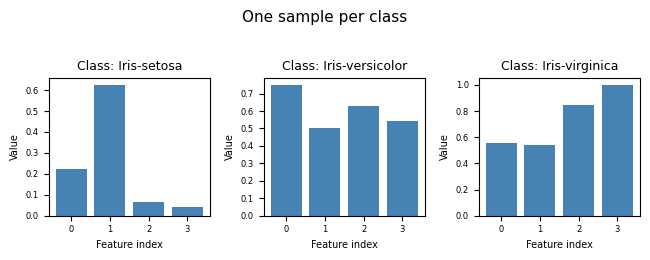

In [ ]:
from sklearn.preprocessing import LabelEncoder

def _is_id_column(series):
    """Return True if a column looks like an auto-increment ID (0,1,2,… or 1,2,3,…)."""
    try:
        vals = series.astype(float).values
        return np.array_equal(vals, np.arange(len(vals))) or \
               np.array_equal(vals, np.arange(1, len(vals) + 1))
    except Exception:
        return False


def load_and_prepare_mnist(csv_file=None, test_size=0.2, random_state=42, use_csv=False):
    """
    Universal loader: handles MNIST-style CSVs, the Iris CSV, or any
    labelled tabular CSV, as well as the auto-download sklearn path.

    CSV auto-detection rules
    ------------------------
    1. Drop any column that looks like an auto-increment ID.
    2. If the LAST column is non-numeric (strings) → use it as label.
    3. Else if the FIRST column is named 'label' / 'class' / 'digit' → use it.
    4. Else fall back to the first column as label (original MNIST convention).
    5. Normalise features: pixel data (0-255 ints) → divide by 255;
       already-float data → leave as-is.

    Arguments:
        csv_file     (str)  : Path to CSV (used when use_csv=True).
        test_size    (float): Test split proportion.
        random_state (int)  : Random seed.
        use_csv      (bool) : True → CSV path; False → sklearn MNIST download.
    Returns:
        X_train, X_test, y_train, y_test
    """
    label_names = None

    if use_csv:
        print(f'Loading from CSV: {csv_file} ...')
        df = pd.read_csv(csv_file)
        print(f'Raw shape: {df.shape}  |  Columns: {list(df.columns)}')

        # ── 1. Drop ID-like columns ───────────────────────────────
        id_cols = [c for c in df.columns if _is_id_column(df[c])]
        if id_cols:
            print(f'  Dropping ID column(s): {id_cols}')
            df = df.drop(columns=id_cols)

        # ── 2. Find label column ──────────────────────────────────
        last_col  = df.columns[-1]
        first_col = df.columns[0]
        label_keywords = {'label', 'class', 'digit', 'target', 'species',
                          'variety', 'category', 'type'}

        if not pd.api.types.is_numeric_dtype(df[last_col]):
            label_col = last_col
            print(f'  Detected string label column: "{label_col}" (last column)')
        elif first_col.lower() in label_keywords:
            label_col = first_col
            print(f'  Detected label column by name: "{label_col}"')
        elif last_col.lower() in label_keywords:
            label_col = last_col
            print(f'  Detected label column by name: "{label_col}"')
        else:
            label_col = first_col
            print(f'  Defaulting to first column as label: "{label_col}"')

        # ── 3. Encode labels ──────────────────────────────────────
        raw_labels = df[label_col].values
        le = LabelEncoder()
        y  = le.fit_transform(raw_labels)           # integer-encoded
        label_names = list(le.classes_)             # keep for display
        print(f'  Classes ({len(label_names)}): {label_names}')

        # ── 4. Feature matrix ─────────────────────────────────────
        X = df.drop(columns=[label_col]).select_dtypes(include=[np.number]).values
        X = X.astype(np.float64)

        # ── 5. Normalise ──────────────────────────────────────────
        # Pixel data: integers mostly in 0-255  → divide by 255
        # Other data: already float / small range → min-max scale
        if X.max() > 1.0 and np.issubdtype(df.drop(columns=[label_col])
                                             .select_dtypes(include=[np.number])
                                             .dtypes[0], np.integer):
            print('  Normalising pixel values ÷ 255')
            X = X / 255.0
        elif X.max() > 1.0:
            col_min, col_max = X.min(axis=0), X.max(axis=0)
            rng = np.where(col_max - col_min == 0, 1, col_max - col_min)
            X = (X - col_min) / rng
            print('  Applied min-max normalisation (feature range was > 1)')
        else:
            print('  Features already in [0, 1] — no normalisation applied')

    else:
        # ── Auto-download MNIST via sklearn ───────────────────────
        print('Fetching MNIST via sklearn (first run ~30 s) ...')
        from sklearn.datasets import fetch_openml
        mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
        X = mnist.data.astype(np.float64) / 255.0
        y = mnist.target.astype(int)

    print(f'\nFinal shapes  →  X: {X.shape}, y: {y.shape}')

    # Train / test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )
    print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')

    # Visualise one sample per class
    plot_sample_images(X, y, label_names=label_names)

    return X_train, X_test, y_train, y_test


# ── Load data ─────────────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = load_and_prepare_mnist(
    csv_file     = CSV_PATH,
    test_size    = 0.2,
    random_state = 42,
    use_csv      = USE_CSV
)

---
## 3.5 Training the Model

In [ ]:
# ── Shape check ───────────────────────────────────────────────────────────────
assert len(X_train) == len(y_train), (
    f'Error: X and y have different lengths! X={len(X_train)}, y={len(y_train)}'
)
print('Move forward: Dimension of Feature Matrix X and label vector y matched.')

Move forward: Dimension of Feature Matrix X and label vector y matched.


In [ ]:
# ── One-hot encode labels ─────────────────────────────────────────────────────
if len(y_train.shape) == 1:
    encoder = OneHotEncoder(sparse_output=False)
    y_train = encoder.fit_transform(y_train.reshape(-1, 1))
    y_test  = encoder.transform(y_test.reshape(-1, 1))

print(f'y_train shape after one-hot encoding: {y_train.shape}')
print(f'y_test  shape after one-hot encoding: {y_test.shape}')

y_train shape after one-hot encoding: (120, 3)
y_test  shape after one-hot encoding: (30, 3)


In [ ]:
# ── Initialise parameters ────────────────────────────────────────────────────
d = X_train.shape[1]   # Number of features (784 for MNIST)
c = y_train.shape[1]   # Number of classes  (10 digits)

np.random.seed(42)
W = np.random.randn(d, c) * 0.01   # Small random weights
b = np.zeros(c)                     # Biases initialised to 0

# ── Hyperparameters ──────────────────────────────────────────────────────────
alpha  = 0.1    # Learning rate
n_iter = 1000   # Number of gradient descent iterations

print(f'Weight matrix W: {W.shape}  |  Bias vector b: {b.shape}')
print(f'Learning rate: {alpha}  |  Iterations: {n_iter}')
print('\nStarting training...')

# ── Train ────────────────────────────────────────────────────────────────────
W_opt, b_opt, cost_history = gradient_descent_softmax(
    X_train, y_train, W, b, alpha, n_iter, show_cost=True
)

print('\nTraining complete!')

Weight matrix W: (4, 3)  |  Bias vector b: (3,)
Learning rate: 0.1  |  Iterations: 1000

Starting training...
Iteration     0 | Cost: 1.094103
Iteration   100 | Cost: 0.752847
Iteration   200 | Cost: 0.616435
Iteration   300 | Cost: 0.542895
Iteration   400 | Cost: 0.495410
Iteration   500 | Cost: 0.461204
Iteration   600 | Cost: 0.434797
Iteration   700 | Cost: 0.413435
Iteration   800 | Cost: 0.395571
Iteration   900 | Cost: 0.380259
Iteration   999 | Cost: 0.367009

Training complete!


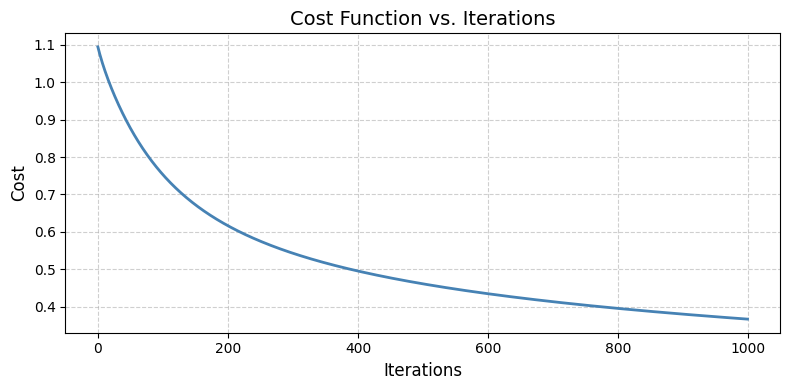

Final cost: 0.367009


In [ ]:
# ── Plot cost curve ───────────────────────────────────────────────────────────
plt.figure(figsize=(8, 4))
plt.plot(cost_history, color='steelblue', linewidth=2)
plt.title('Cost Function vs. Iterations', fontsize=14)
plt.xlabel('Iterations', fontsize=12)
plt.ylabel('Cost', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()
print(f'Final cost: {cost_history[-1]:.6f}')

---
## 3.6 Evaluating Model Performance

In [ ]:
def evaluate_classification(y_true, y_pred):
    """
    Evaluate classification performance using confusion matrix,
    precision, recall, and F1-score.

    Parameters:
        y_true (numpy.ndarray): True integer labels.
        y_pred (numpy.ndarray): Predicted integer labels.
    Returns:
        tuple: (confusion_matrix, precision, recall, f1)
    """
    cm        = confusion_matrix(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    recall    = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1        = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    return cm, precision, recall, f1

In [ ]:
# ── Predict on test set ───────────────────────────────────────────────────────
y_pred_test  = predict_softmax(X_test, W_opt, b_opt)
y_test_labels = np.argmax(y_test, axis=1)   # Convert one-hot back to integer labels

# ── Compute metrics ───────────────────────────────────────────────────────────
cm, precision, recall, f1 = evaluate_classification(y_test_labels, y_pred_test)

print('\nConfusion Matrix:')
print(cm)
print(f'\nPrecision : {precision:.4f}')
print(f'Recall    : {recall:.4f}')
print(f'F1-Score  : {f1:.4f}')

# Overall accuracy
accuracy = np.mean(y_pred_test == y_test_labels)
print(f'Accuracy  : {accuracy:.4f}')


Confusion Matrix:
[[10  0  0]
 [ 0  8  1]
 [ 0  0 11]]

Precision : 0.9694
Recall    : 0.9667
F1-Score  : 0.9664
Accuracy  : 0.9667


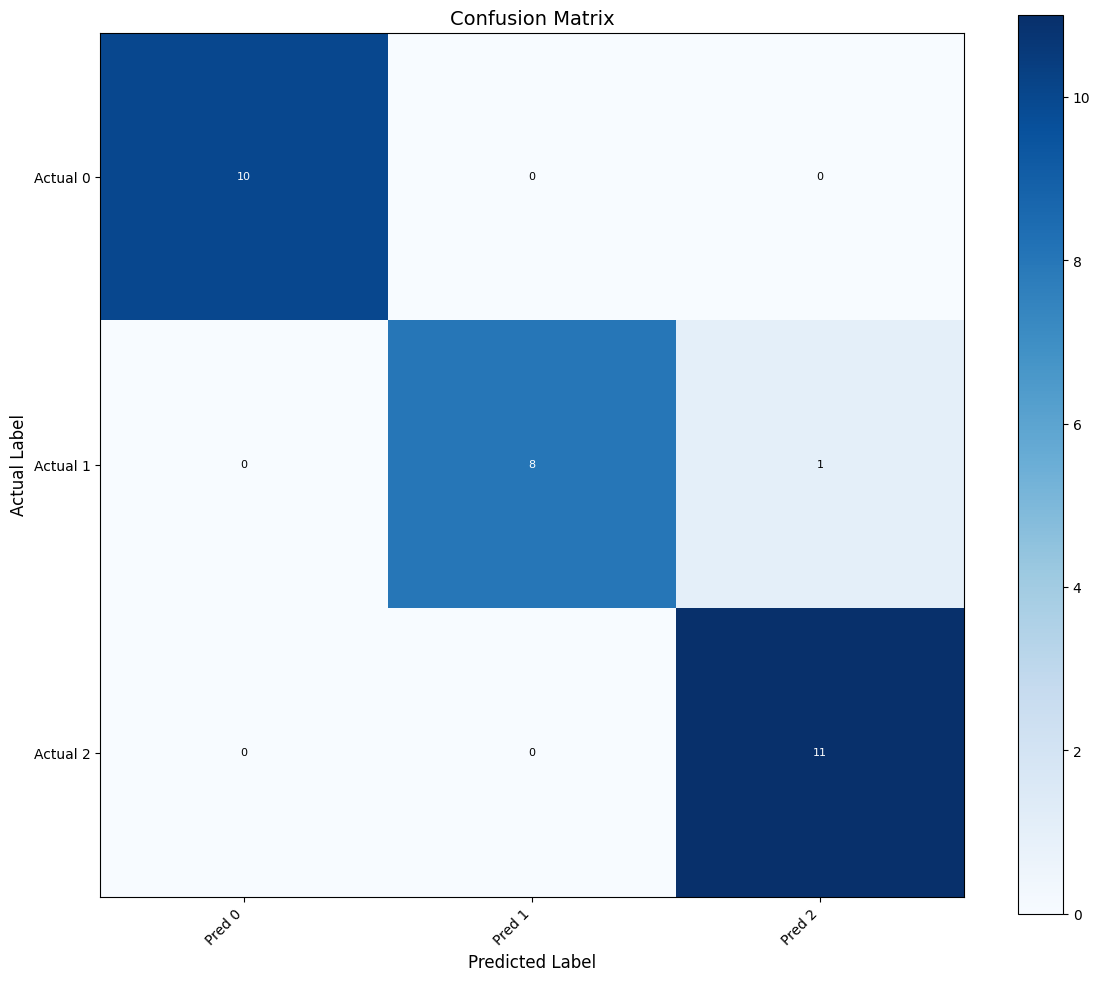

In [ ]:
# ── Visualise Confusion Matrix ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 10))
cax = ax.imshow(cm, cmap='Blues')

num_classes = cm.shape[0]
ax.set_xticks(range(num_classes))
ax.set_yticks(range(num_classes))
ax.set_xticklabels([f'Pred {i}' for i in range(num_classes)], rotation=45, ha='right')
ax.set_yticklabels([f'Actual {i}' for i in range(num_classes)])

threshold = np.max(cm) / 2
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                color='white' if cm[i, j] > threshold else 'black', fontsize=8)

ax.grid(False)
plt.title('Confusion Matrix', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('Actual Label', fontsize=12)
plt.colorbar(cax)
plt.tight_layout()
plt.show()

---
## 4. Exercise – Linear Separability and Logistic Regression

In [ ]:
from sklearn.datasets import make_classification, make_circles
from sklearn.linear_model import LogisticRegression

np.random.seed(42)

# ── Linearly separable dataset ────────────────────────────────────────────────
X_linear_separable, y_linear_separable = make_classification(
    n_samples=200, n_features=2, n_informative=2,
    n_redundant=0, n_clusters_per_class=1, random_state=42
)
X_train_linear, X_test_linear, y_train_linear, y_test_linear = train_test_split(
    X_linear_separable, y_linear_separable, test_size=0.2, random_state=42
)
logistic_model_linear_separable = LogisticRegression()
logistic_model_linear_separable.fit(X_train_linear, y_train_linear)

# ── Non-linearly separable dataset (circles) ──────────────────────────────────
X_non_linear_separable, y_non_linear_separable = make_circles(
    n_samples=200, noise=0.1, factor=0.5, random_state=42
)
X_train_non_linear, X_test_non_linear, y_train_non_linear, y_test_non_linear = train_test_split(
    X_non_linear_separable, y_non_linear_separable, test_size=0.2, random_state=42
)
logistic_model_non_linear_separable = LogisticRegression()
logistic_model_non_linear_separable.fit(X_train_non_linear, y_train_non_linear)

print('Both logistic regression models trained!')

Both logistic regression models trained!


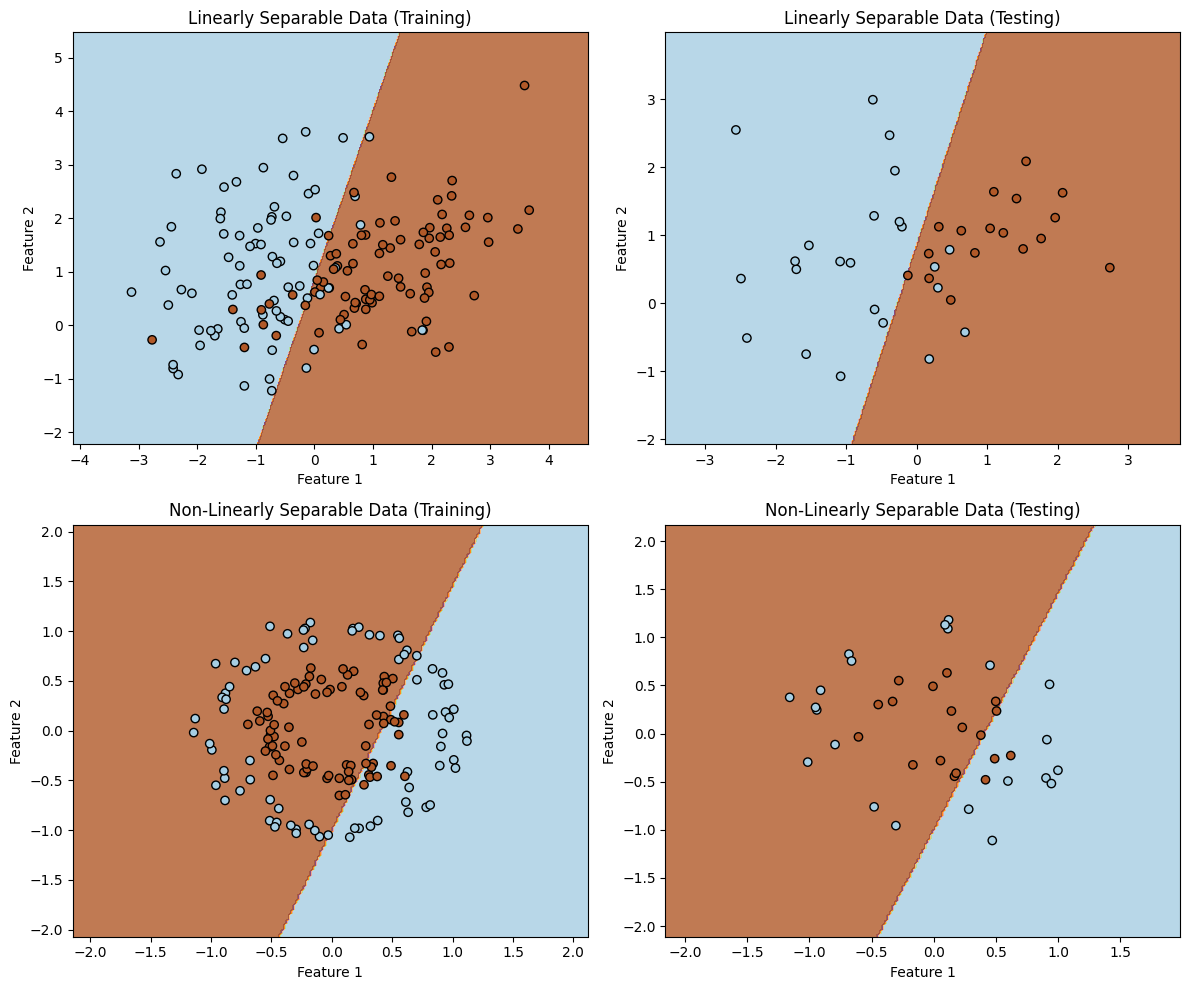

Plot saved as decision_boundaries.png


In [ ]:
def plot_decision_boundary(ax, model, X, y, title):
    h = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.Paired)
    ax.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap=plt.cm.Paired)
    ax.set_title(title)
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')


fig, axes = plt.subplots(2, 2, figsize=(12, 10))

plot_decision_boundary(axes[0, 0], logistic_model_linear_separable,
                       X_train_linear, y_train_linear,
                       'Linearly Separable Data (Training)')
plot_decision_boundary(axes[0, 1], logistic_model_linear_separable,
                       X_test_linear, y_test_linear,
                       'Linearly Separable Data (Testing)')
plot_decision_boundary(axes[1, 0], logistic_model_non_linear_separable,
                       X_train_non_linear, y_train_non_linear,
                       'Non-Linearly Separable Data (Training)')
plot_decision_boundary(axes[1, 1], logistic_model_non_linear_separable,
                       X_test_non_linear, y_test_non_linear,
                       'Non-Linearly Separable Data (Testing)')

plt.tight_layout()
plt.savefig('decision_boundaries.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved as decision_boundaries.png')

### Question 2 – Interpretation of the Decision Boundary Plots

**Linearly Separable Data (top row):**  
The training and testing plots both show a clean, straight diagonal boundary dividing the two coloured regions. Because the data was generated so that one straight line can perfectly separate the two classes, Logistic Regression finds this boundary efficiently. The decision boundary generalises well — the test-set plot looks almost identical to the training-set plot — indicating low variance and no significant overfitting.

**Non-Linearly Separable Data (bottom row):**  
The data consists of two concentric circles (inner vs. outer ring), so **no single straight line** can separate them. Logistic Regression is a linear model and can only produce a linear boundary; it is therefore forced to draw a diagonal line that cuts across both classes. The result is poor classification — many inner-circle points are mislabelled as outer-circle (and vice versa) in both the training and testing plots. This demonstrates the fundamental limitation of linear classifiers on non-linearly separable data. A model with a non-linear decision boundary (e.g., an SVM with an RBF kernel, or a neural network) would be needed here.

---

### Question 3 – Challenges Faced

1. **Numerical stability in softmax** – Computing `exp(z)` directly for large `z` values causes overflow (values become `inf`). This was resolved by subtracting the row-wise maximum before exponentiating (the log-sum-exp trick).

2. **Log of zero in the loss function** – If the model is completely confident in the wrong class, a predicted probability can become 0, making `log(0) = -inf`. This was handled by clipping predictions to a small epsilon range `[1e-15, 1 - 1e-15]`.

3. **Training time on full MNIST** – The full 70,000-sample MNIST dataset makes each gradient computation slow when running pure NumPy gradient descent without batching. This is expected for a vanilla implementation; mini-batch gradient descent would be the standard fix.

4. **One-hot encoding shape mismatch** – The gradient and cost functions expect `y` to be one-hot encoded `(n, c)`, but raw MNIST labels are integer arrays `(n,)`. The `OneHotEncoder` step is therefore critical before training.